In [1]:
# Import libraries
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import gensim
from gensim.models import Word2Vec
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Add src to path
sys.path.append('..')
from src.features.builder import FeatureBuilder
from src.data.cleaner import DataCleaner

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

In [2]:
# Load data from previous notebook
print("="*60)
print("LOADING PROCESSED DATA")
print("="*60)

train_path = '../data/processed/train_processed.csv'
test_path = '../data/processed/test_processed.csv'

if os.path.exists(train_path):
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)
    print(f"✅ Loaded training data: {df_train.shape}")
    print(f"✅ Loaded test data: {df_test.shape}")
else:
    print("❌ Processed data not found. Please run Notebook 01 first.")
    # Create sample data as fallback
    from sklearn.datasets import make_classification
    # ... (fallback code)

LOADING PROCESSED DATA
✅ Loaded training data: (8000, 5)
✅ Loaded test data: (2000, 3)


In [3]:
# Define text cleaning function
print("="*60)
print("TEXT CLEANING")
print("="*60)

def clean_text(text):
    """Clean a single text string"""
    if not isinstance(text, str):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove special characters
    text = re.sub(r'[^\w\s]', '', text)
    
    return text

def preprocess_text(text, remove_stopwords=True, do_stemming=True):
    """Complete preprocessing pipeline"""
    # Clean
    text = clean_text(text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        tokens = [t for t in tokens if t not in stop_words]
    
    # Stemming
    if do_stemming:
        stemmer = PorterStemmer()
        tokens = [stemmer.stem(t) for t in tokens]
    
    # Join back
    return ' '.join(tokens)

# Test on a sample
sample_text = df_train['review_text'].iloc[0]
print(f"\nOriginal text: {sample_text[:200]}...")
print(f"\nCleaned text: {clean_text(sample_text)[:200]}...")
print(f"\nPreprocessed text: {preprocess_text(sample_text)[:200]}...")

TEXT CLEANING

Original text: Complete waste, regret buying....

Cleaned text: complete waste regret buying...

Preprocessed text: complet wast regret buy...


In [4]:
# Apply preprocessing to all texts
print("="*60)
print("APPLYING PREPROCESSING TO ALL TEXTS")
print("="*60)

# Process training data
print("\n📊 Processing training data...")
df_train['review_clean'] = df_train['review_text'].astype(str).apply(
    lambda x: preprocess_text(x, remove_stopwords=True, do_stemming=True)
)
df_train['review_length_clean'] = df_train['review_clean'].str.split().str.len()

# Process test data
print("📊 Processing test data...")
df_test['review_clean'] = df_test['review_text'].astype(str).apply(
    lambda x: preprocess_text(x, remove_stopwords=True, do_stemming=True)
)
df_test['review_length_clean'] = df_test['review_clean'].str.split().str.len()

print(f"\n✅ Training data shape after preprocessing: {df_train.shape}")
print(f"✅ Test data shape after preprocessing: {df_test.shape}")

# Show examples
print("\n📋 Sample preprocessed reviews:")
for i in range(3):
    print(f"\n{i+1}. Original: {df_train['review_text'].iloc[i][:100]}...")
    print(f"   Cleaned: {df_train['review_clean'].iloc[i][:100]}...")

APPLYING PREPROCESSING TO ALL TEXTS

📊 Processing training data...


📊 Processing test data...



✅ Training data shape after preprocessing: (8000, 7)
✅ Test data shape after preprocessing: (2000, 5)

📋 Sample preprocessed reviews:

1. Original: Complete waste, regret buying....
   Cleaned: complet wast regret buy...

2. Original: Love this item, worth every penny. Very happy with it....
   Cleaned: love item worth everi penni happi...

3. Original: Best product I've ever bought....
   Cleaned: best product ive ever bought...


In [5]:
# TF-IDF Vectorization
print("="*60)
print("TF-IDF VECTORIZATION")
print("="*60)

# Initialize TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8,
    stop_words='english'
)

# Fit on training data and transform
print("\n🔄 Fitting TF-IDF on training data...")
X_train_tfidf = tfidf_vectorizer.fit_transform(df_train['review_clean'])
print(f"  • Training TF-IDF shape: {X_train_tfidf.shape}")

# Transform test data
X_test_tfidf = tfidf_vectorizer.transform(df_test['review_clean'])
print(f"  • Test TF-IDF shape: {X_test_tfidf.shape}")

# Get feature names
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"  • Number of features: {len(feature_names)}")

# Show top features by IDF (rare words have high IDF)
idf_scores = tfidf_vectorizer.idf_
top_rare_indices = np.argsort(idf_scores)[-10:][::-1]
print("\n📊 Top 10 rarest words (highest IDF):")
for idx in top_rare_indices:
    print(f"  • {feature_names[idx]}: {idf_scores[idx]:.2f}")

# Show most common words (low IDF)
top_common_indices = np.argsort(idf_scores)[:10]
print("\n📊 Top 10 most common words (lowest IDF):")
for idx in top_common_indices:
    print(f"  • {feature_names[idx]}: {idf_scores[idx]:.2f}")

TF-IDF VECTORIZATION

🔄 Fitting TF-IDF on training data...
  • Training TF-IDF shape: (8000, 204)
  • Test TF-IDF shape: (2000, 204)
  • Number of features: 204

📊 Top 10 rarest words (highest IDF):
  • qualiti happi: 7.59
  • apart sure: 7.15
  • price mayb: 7.04
  • work sure: 6.99
  • poor definit: 6.94
  • price definit: 6.94
  • use sure: 6.94
  • away sure: 6.94
  • use mayb: 6.94
  • away recommend: 6.94

📊 Top 10 most common words (lowest IDF):
  • product: 2.30
  • qualiti: 2.63
  • buy: 2.69
  • recommend: 2.79
  • work: 3.26
  • sure: 3.27
  • happi: 3.29
  • purchas: 3.29
  • worth: 3.32
  • someth els: 3.33


TF-IDF FEATURE ANALYSIS

📊 Top 20 words by average TF-IDF score:
   1. product: 0.0580
   2. buy: 0.0538
   3. qualiti: 0.0529
   4. recommend: 0.0457
   5. purchas: 0.0387
   6. star: 0.0358
   7. star buy: 0.0358
   8. work: 0.0348
   9. satisfi purchas: 0.0343
  10. satisfi: 0.0343
  11. perfect need: 0.0315
  12. need: 0.0315
  13. perfect: 0.0315
  14. sure: 0.0308
  15. happi: 0.0305
  16. perfectli: 0.0283
  17. awesom work: 0.0283
  18. awesom: 0.0283
  19. work perfectli: 0.0283
  20. servic: 0.0282


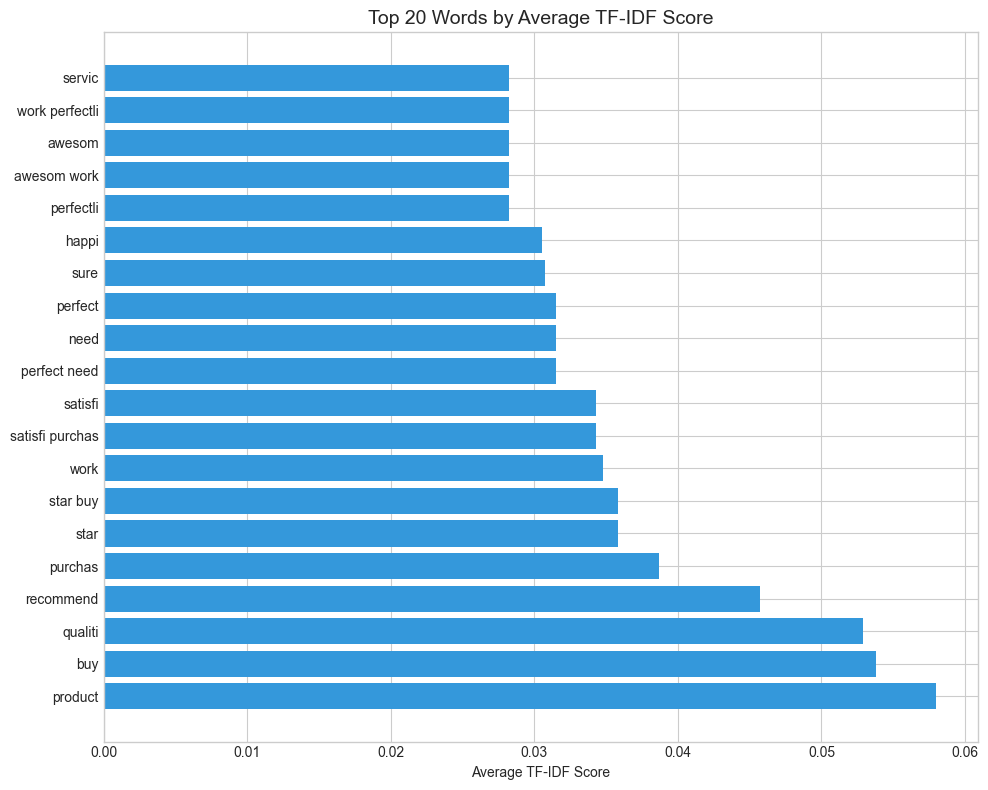

In [6]:
# Analyze TF-IDF features
print("="*60)
print("TF-IDF FEATURE ANALYSIS")
print("="*60)

# Get average TF-IDF scores per word
avg_tfidf = np.array(X_train_tfidf.mean(axis=0)).flatten()
top_word_indices = np.argsort(avg_tfidf)[-20:][::-1]

print("\n📊 Top 20 words by average TF-IDF score:")
for i, idx in enumerate(top_word_indices, 1):
    print(f"  {i:2d}. {feature_names[idx]}: {avg_tfidf[idx]:.4f}")

# Visualize
plt.figure(figsize=(10, 8))
top_words = [feature_names[i] for i in top_word_indices]
top_scores = [avg_tfidf[i] for i in top_word_indices]

plt.barh(range(len(top_words)), top_scores, color='#3498db')
plt.yticks(range(len(top_words)), top_words)
plt.xlabel('Average TF-IDF Score')
plt.title('Top 20 Words by Average TF-IDF Score', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# Word2Vec Embeddings
print("="*60)
print("WORD2VEC EMBEDDINGS")
print("="*60)

# Tokenize texts for Word2Vec
tokenized_texts = [text.split() for text in df_train['review_clean'].tolist()]

# Train Word2Vec model
print("\n🔄 Training Word2Vec model...")
word2vec_model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=10
)

print(f"  • Vocabulary size: {len(word2vec_model.wv.key_to_index)}")
print(f"  • Vector size: {word2vec_model.wv.vector_size}")

# Get document vectors (average of word vectors)
def get_doc_vector(tokens, model, vector_size=100):
    """Get document vector as average of word vectors"""
    word_vectors = [model.wv[word] for word in tokens if word in model.wv.key_to_index]
    if word_vectors:
        return np.mean(word_vectors, axis=0)
    else:
        return np.zeros(vector_size)

print("\n🔄 Computing document vectors...")
X_train_w2v = np.array([get_doc_vector(text.split(), word2vec_model) 
                        for text in df_train['review_clean']])
X_test_w2v = np.array([get_doc_vector(text.split(), word2vec_model) 
                       for text in df_test['review_clean']])

print(f"  • Training W2V shape: {X_train_w2v.shape}")
print(f"  • Test W2V shape: {X_test_w2v.shape}")

# Show similar words example
# print("\n📊 Words similar to 'good':")
# similar_words = word2vec_model.wv.most_similar('good', topn=10)
# for word, score in similar_words:
#     print(f"  • {word}: {score:.4f}")

WORD2VEC EMBEDDINGS

🔄 Training Word2Vec model...
  • Vocabulary size: 63
  • Vector size: 100

🔄 Computing document vectors...


  • Training W2V shape: (8000, 100)
  • Test W2V shape: (2000, 100)


In [8]:
# Combine features
print("="*60)
print("COMBINING FEATURES")
print("="*60)

# Convert sparse TF-IDF to dense for combination
X_train_tfidf_dense = X_train_tfidf.toarray()
X_test_tfidf_dense = X_test_tfidf.toarray()

# Combine TF-IDF and Word2Vec
X_train_combined = np.hstack([X_train_tfidf_dense, X_train_w2v])
X_test_combined = np.hstack([X_test_tfidf_dense, X_test_w2v])

print(f"\n📊 Combined features shape:")
print(f"  • Training: {X_train_combined.shape}")
print(f"  • Test: {X_test_combined.shape}")

# Extract labels
y_train = df_train['label'].values
y_test = df_test['label'].values

# Convert labels: 1=negative, 2=positive -> 0=negative, 1=positive
y_train = (y_train == 2).astype(int)
y_test = (y_test == 2).astype(int)

print(f"\n📊 Labels after conversion:")
print(f"  • Training: 0={np.sum(y_train == 0):,}, 1={np.sum(y_train == 1):,}")
print(f"  • Test: 0={np.sum(y_test == 0):,}, 1={np.sum(y_test == 1):,}")

COMBINING FEATURES

📊 Combined features shape:
  • Training: (8000, 304)
  • Test: (2000, 304)

📊 Labels after conversion:
  • Training: 0=2,409, 1=5,591
  • Test: 0=591, 1=1,409


In [9]:
# Save features
print("="*60)
print("SAVING FEATURES")
print("="*60)

# Create features directory
os.makedirs('../data/processed/features', exist_ok=True)

# Save numpy arrays
np.save('../data/processed/features/X_train_tfidf.npy', X_train_tfidf_dense)
np.save('../data/processed/features/X_test_tfidf.npy', X_test_tfidf_dense)
np.save('../data/processed/features/X_train_w2v.npy', X_train_w2v)
np.save('../data/processed/features/X_test_w2v.npy', X_test_w2v)
np.save('../data/processed/features/X_train_combined.npy', X_train_combined)
np.save('../data/processed/features/X_test_combined.npy', X_test_combined)
np.save('../data/processed/features/y_train.npy', y_train)
np.save('../data/processed/features/y_test.npy', y_test)

# Save models
os.makedirs('../outputs/models', exist_ok=True)
import joblib
joblib.dump(tfidf_vectorizer, '../outputs/models/tfidf_vectorizer.pkl')
word2vec_model.save('../outputs/models/word2vec.model')

print(f"✅ Saved TF-IDF features")
print(f"✅ Saved Word2Vec features")
print(f"✅ Saved combined features")
print(f"✅ Saved labels")
print(f"✅ Saved models")

# Save processed data with clean text
df_train.to_csv('../data/processed/train_clean.csv', index=False)
df_test.to_csv('../data/processed/test_clean.csv', index=False)

print(f"\n✅ Preprocessing complete! Ready for next notebook.")

SAVING FEATURES
✅ Saved TF-IDF features
✅ Saved Word2Vec features
✅ Saved combined features
✅ Saved labels
✅ Saved models



✅ Preprocessing complete! Ready for next notebook.
